<a href="https://colab.research.google.com/github/theochi/MachineLearning/blob/main/HW3/churn_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

df = pd.read_csv(Path('WA_Fn-UseC_-Telco-Customer-Churn.csv'))
print('Shape:', df.shape)

Shape: (7043, 21)


Task 2

In [ ]:
print(df.head().to_string())
print('\nData types and non-null counts:')
df.info()
print('\nNumerical summary:')
print(df.describe().to_string())
print('\nSelected categorical columns:')
print(df[['TotalCharges', 'Contract', 'PaymentMethod']].describe().to_string())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling              PaymentMethod  MonthlyCharges TotalCharges Churn
0  7590-VHVEG  Female              0     Yes         No       1           No  No phone service             DSL             No          Yes               No          No          No              No  Month-to-month              Yes           Electronic check           29.85        29.85    No
1  5575-GNVDE    Male              0      No         No      34          Yes                No             DSL            Yes           No              Yes          No          No              No        One year               No               Mailed check           56.95       1889.5    No
2  3668-QPYBK    Male              0      No         No       2          Yes                No             DSL            Yes  

Task 3

In [ ]:
df = df.drop(columns='customerID')
print('Columns after dropping customerID:', len(df.columns))

Columns after dropping customerID: 20


Task 4

In [ ]:
print('Explicit missing values before conversion:')
print(df.isna().sum().to_string())
blank_counts = df.select_dtypes(include='object').apply(lambda col: col.str.strip().eq('').sum())
print('\nWhitespace-only values:')
print(blank_counts[blank_counts > 0].to_string())
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(r'^\s*$', np.nan, regex=True), errors='coerce')
print('\nMissing values after conversion:')
print(df.isna().sum()[lambda s: s > 0].to_string())
print('Numerical missing values will use the training-set median; categorical missing values will use the training-set mode.')

Explicit missing values before conversion:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0

Whitespace-only values:
TotalCharges    11

Missing values after conversion:
TotalCharges    11
Numerical missing values will use the training-set median; categorical missing values will use the training-set mode.


Task 5

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler

X = df.drop(columns='Churn')
y = (df['Churn'] == 'Yes').astype(int)
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
print('Numerical:', numeric_features)
print('Categorical:', categorical_features)

def make_preprocessor(scaler):
    numeric = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', scaler)])
    categorical = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                            ('onehot', OneHotEncoder(handle_unknown='ignore'))])
    return ColumnTransformer([('numeric', numeric, numeric_features),
                              ('categorical', categorical, categorical_features)])

Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Task 6

In [ ]:
from sklearn.linear_model import SGDClassifier

def make_model(scaler):
    return Pipeline([('preprocess', make_preprocessor(scaler)),
                     ('classifier', SGDClassifier(loss='log_loss', random_state=42, max_iter=2000, tol=1e-4))])
print(make_model(StandardScaler()))

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                  

Task 7


80/20 | StandardScaler
Confusion matrix:
 [[940  95]
 [185 189]]
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.8401; training iterations: 89

80/20 | MinMaxScaler
Confusion matrix:
 [[894 141]
 [162 212]]
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1035
           1       0.60      0.57      0.58       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409

ROC-AUC: 0.8381; training iterations: 81

70/30 | StandardScaler
Confusion matrix:
 [[1396  156]
 [ 259  302]]
              precision    recall  f1-score   support

         

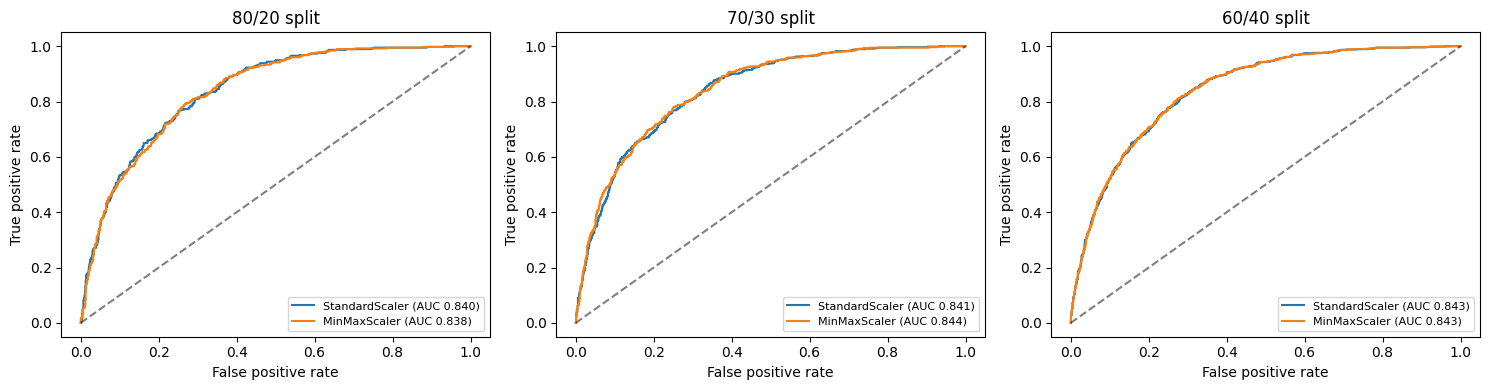


Comparison:
train/test         scaler  ROC-AUC  iterations
     80/20 StandardScaler 0.840084          89
     80/20   MinMaxScaler 0.838123          81
     70/30 StandardScaler 0.840966          68
     70/30   MinMaxScaler 0.843727          59
     60/40 StandardScaler 0.843108          89
     60/40   MinMaxScaler 0.843406          89


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

results = []
models = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, test_size in zip(axes, [0.20, 0.30, 0.40]):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y)
    for scaler_name, scaler in [('StandardScaler', StandardScaler()), ('MinMaxScaler', MinMaxScaler())]:
        model = make_model(scaler)
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        probabilities = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, probabilities)
        results.append({'train/test': f'{int((1-test_size)*100)}/{int(test_size*100)}',
                        'scaler': scaler_name, 'ROC-AUC': auc,
                        'iterations': model.named_steps['classifier'].n_iter_})
        models[(test_size, scaler_name)] = model
        print(f'\n{int((1-test_size)*100)}/{int(test_size*100)} | {scaler_name}')
        print('Confusion matrix:\n', confusion_matrix(y_test, predictions))
        print(classification_report(y_test, predictions, zero_division=0))
        print(f'ROC-AUC: {auc:.4f}; training iterations: {model.named_steps["classifier"].n_iter_}')
        fpr, tpr, _ = roc_curve(y_test, probabilities)
        ax.plot(fpr, tpr, label=f'{scaler_name} (AUC {auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=.5)
    ax.set(title=f'{int((1-test_size)*100)}/{int(test_size*100)} split', xlabel='False positive rate', ylabel='True positive rate')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
summary = pd.DataFrame(results)
print('\nComparison:')
print(summary.to_string(index=False))

Task 8

In [ ]:
selected_model = models[(0.20, 'StandardScaler')]
feature_names = selected_model.named_steps['preprocess'].get_feature_names_out()
coefficients = pd.Series(selected_model.named_steps['classifier'].coef_[0], index=feature_names)
print('Strongest positive churn coefficients:')
print(coefficients.nlargest(8).round(3).to_string())
print('\nStrongest negative churn coefficients:')
print(coefficients.nsmallest(8).round(3).to_string())
print('Positive values indicate higher predicted churn, conditional on the other encoded features.')

Strongest positive churn coefficients:
categorical__InternetService_Fiber optic    1.359
categorical__Contract_Month-to-month        0.992
categorical__StreamingTV_Yes                0.834
categorical__PaperlessBilling_Yes           0.674
categorical__OnlineSecurity_No              0.642
categorical__StreamingMovies_Yes            0.615
categorical__PhoneService_Yes               0.604
categorical__DeviceProtection_Yes           0.585

Strongest negative churn coefficients:
numeric__tenure                                     -1.256
numeric__MonthlyCharges                             -1.110
categorical__InternetService_DSL                    -0.463
categorical__Contract_Two year                      -0.380
categorical__InternetService_No                      0.003
categorical__OnlineSecurity_No internet service      0.003
categorical__OnlineBackup_No internet service        0.003
categorical__DeviceProtection_No internet service    0.003
Positive values indicate higher predicted churn, 